### 2-Point Ray Tracing

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [57.14285714285714, 142.85714285714286, 114.28571428571428, 85.71428571428572, 171.42857142857142, 28.571428571428584]
 * Zero: [33.88835065025407, 166.11164934975073, 79.02712656845686, 120.97287343155251, 139.23228749310272, 60.7677125069267]
 * Inf-norm of residuals: 0.000000
 * Iterations: 3
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 4
 * Jacobian Calls (df/dx): 4

 ray has the following fields: (:xk0, :xk, :t0, :t)

 Traveltimes:
Initial: 0.17423822430627878
Final:   0.17172661202553888



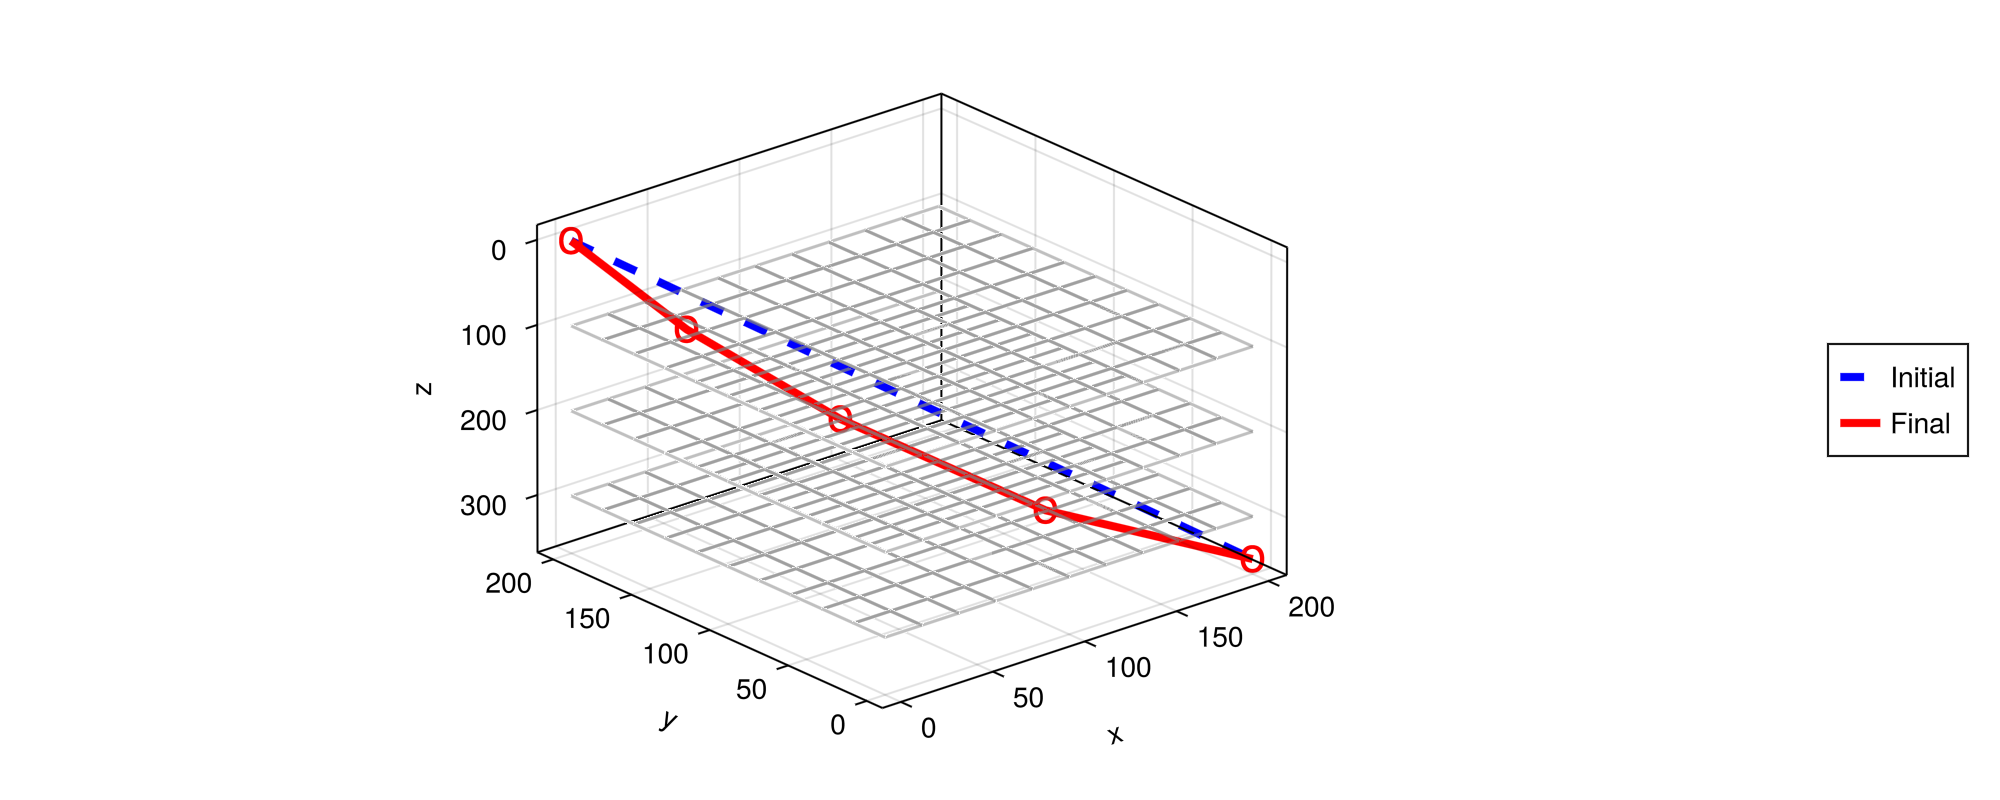

GLMakie.Screen(...)

In [ ]:
using SeisTimes
using GLMakie
Makie.inline!(true)

# define layer properties and interface depths
vp_layers = [2000, 2500, 3000, 4000];
vs_layers = [1000, 1500, 2000, 2500];
eps1_layers = [0, 0.05, 0, 0]
eps2_layers = [0, 0.1, 0, 0]
gam1_layers = [0, 0.1, 0, 0]
gam2_layers = [0, 0.2, 0, 0]
del1_layers = [0, -0.1, 0, 0]
del2_layers = [0, -0.05, 0, 0]
del3_layers = [0, 0.15, 0, 0]
interface_depths = [100, 200, 300];

# combine into nlayer x 9 matrix
M = hcat(vp_layers, vs_layers, 
        eps1_layers, eps2_layers, 
        gam1_layers, gam2_layers,
        del1_layers, del2_layers, del3_layers)

phase = :P # :P, :S1, :S2
src = (0, 200, 0);
rcv = (200, 0, 350);

# run 2-point ray tracing 
ray = ray_bending(phase, M, interface_depths, src, rcv; verbose=true)
print("\n ray has the following fields: ", fieldnames(typeof(ray)), "\n")

# inital ray segments and travel time (straight connection)
xk0 = ray.xk0 
t0 = ray.t0 

# final ray segments and travel time 
xk = ray.xk
t = ray.t

println("\n Traveltimes:
Initial: $(t0) \n
Final:   $(t)  \n
")

# plot 
x = 0:20:200
y = 0:20:200
X = repeat(transpose(x), length(y), 1) 
Y = repeat(y, 1, length(x))
Z_layers = [fill(z, size(X)) for z in interface_depths]

fig = Figure(size=(1000, 400)) 
ax = Axis3(fig[1,1], zreversed=true)

ini = lines!(ax, [x[1] for x in xk0], 
            [x[2] for x in xk0],
            [x[3] for x in xk0], color=:blue, linestyle=:dash, overdraw=true, linewidth=4)

opt = lines!(ax,  [x[1] for x in xk], 
            [x[2] for x in xk],
            [x[3] for x in xk], color=:red, overdraw=true,linewidth=4)

scatter!(ax,
    [x[1] for x in xk],
    [x[2] for x in xk],
    [x[3] for x in xk],
    color = :red,
    markersize = 25,
    marker = 'o', overdraw=true
)

for layer in Z_layers 
    wireframe!(ax, X,Y,layer, color=:grey, alpha=0.5)
end
Legend(fig[1,2], [ini, opt], ["Initial", "Final"])

display(fig)


### Traveltime Grids

In [8]:
# medium
vp_layers = [2000, 2500, 3000, 4000];
vs_layers = [1000, 1500, 2000, 2500];
# rather strong anisotropy
eps1_layers = [0.1, 0.30, 0.20, 0.0]
eps2_layers = [0.1, 0.38, 0.25, 0.0]
gam1_layers = [0.1, 0.25, 0.18, 0.0]
gam2_layers = [0.1, 0.35, 0.20, 0.0]
del1_layers = [-0.1, -0.20, 0.15, 0.0]
del2_layers = [-0.1, -0.18, 0.12, 0.0]
del3_layers = [0.0,  0.30, -0.10, 0.0]

interface_depths = [250, 500, 750];

# combine into nlayer x 9 matrix
M = hcat(vp_layers, vs_layers, 
        eps1_layers, eps2_layers, 
        gam1_layers, gam2_layers,
        del1_layers, del2_layers, del3_layers)

# create grid 
h = 20
x_coords = 0:h:1000 
y_coords = 0:h:1000
z_coords = 0:h:1000
nx, ny, nz = length(x_coords), length(y_coords), length(z_coords)

# compute travel times 
tt_p = zeros(nx,ny,nz)
tt_s1 = zeros(nx,ny,nz)
tt_s2 = zeros(nx,ny,nz)

src = (500, 500, 500)
for x in 1:nx, y in 1:ny, z in 1:nz
    rcv = (x_coords[x], y_coords[y], z_coords[z])

    if src != rcv
        # P-wave travel time
        try
            tt_p[x,y,z] = ray_bending(:P, M, interface_depths, src, rcv; verbose=false).t
        catch
            println("Failed P-wave at receiver: $rcv (x=$x, y=$y, z=$z)")
        end

        # S1-wave travel time
        try
            tt_s1[x,y,z] = ray_bending(:S1, M, interface_depths, src, rcv; verbose=false).t
        catch
            println("Failed S1-wave at receiver: $rcv (x=$x, y=$y, z=$z)")
        end

        # S2-wave travel time
        try
            tt_s2[x,y,z] = ray_bending(:S2, M, interface_depths, src, rcv; verbose=false).t
        catch
            println("Failed S2-wave at receiver: $rcv (x=$x, y=$y, z=$z)")
        end
    end
end


Failed P-wave at receiver: (500, 500, 760) (x=26, y=26, z=39)
Failed S1-wave at receiver: (500, 500, 760) (x=26, y=26, z=39)
Failed S2-wave at receiver: (500, 500, 760) (x=26, y=26, z=39)
Failed P-wave at receiver: (500, 500, 780) (x=26, y=26, z=40)
Failed S1-wave at receiver: (500, 500, 780) (x=26, y=26, z=40)
Failed S2-wave at receiver: (500, 500, 780) (x=26, y=26, z=40)
Failed P-wave at receiver: (500, 500, 800) (x=26, y=26, z=41)
Failed S1-wave at receiver: (500, 500, 800) (x=26, y=26, z=41)
Failed S2-wave at receiver: (500, 500, 800) (x=26, y=26, z=41)
Failed P-wave at receiver: (500, 500, 820) (x=26, y=26, z=42)
Failed S1-wave at receiver: (500, 500, 820) (x=26, y=26, z=42)
Failed S2-wave at receiver: (500, 500, 820) (x=26, y=26, z=42)
Failed P-wave at receiver: (500, 500, 840) (x=26, y=26, z=43)
Failed S1-wave at receiver: (500, 500, 840) (x=26, y=26, z=43)
Failed S2-wave at receiver: (500, 500, 840) (x=26, y=26, z=43)
Failed P-wave at receiver: (500, 500, 860) (x=26, y=26, z=44

As indicated above, the 2-point ray tracing is not always solvable for every source-receiver combination.

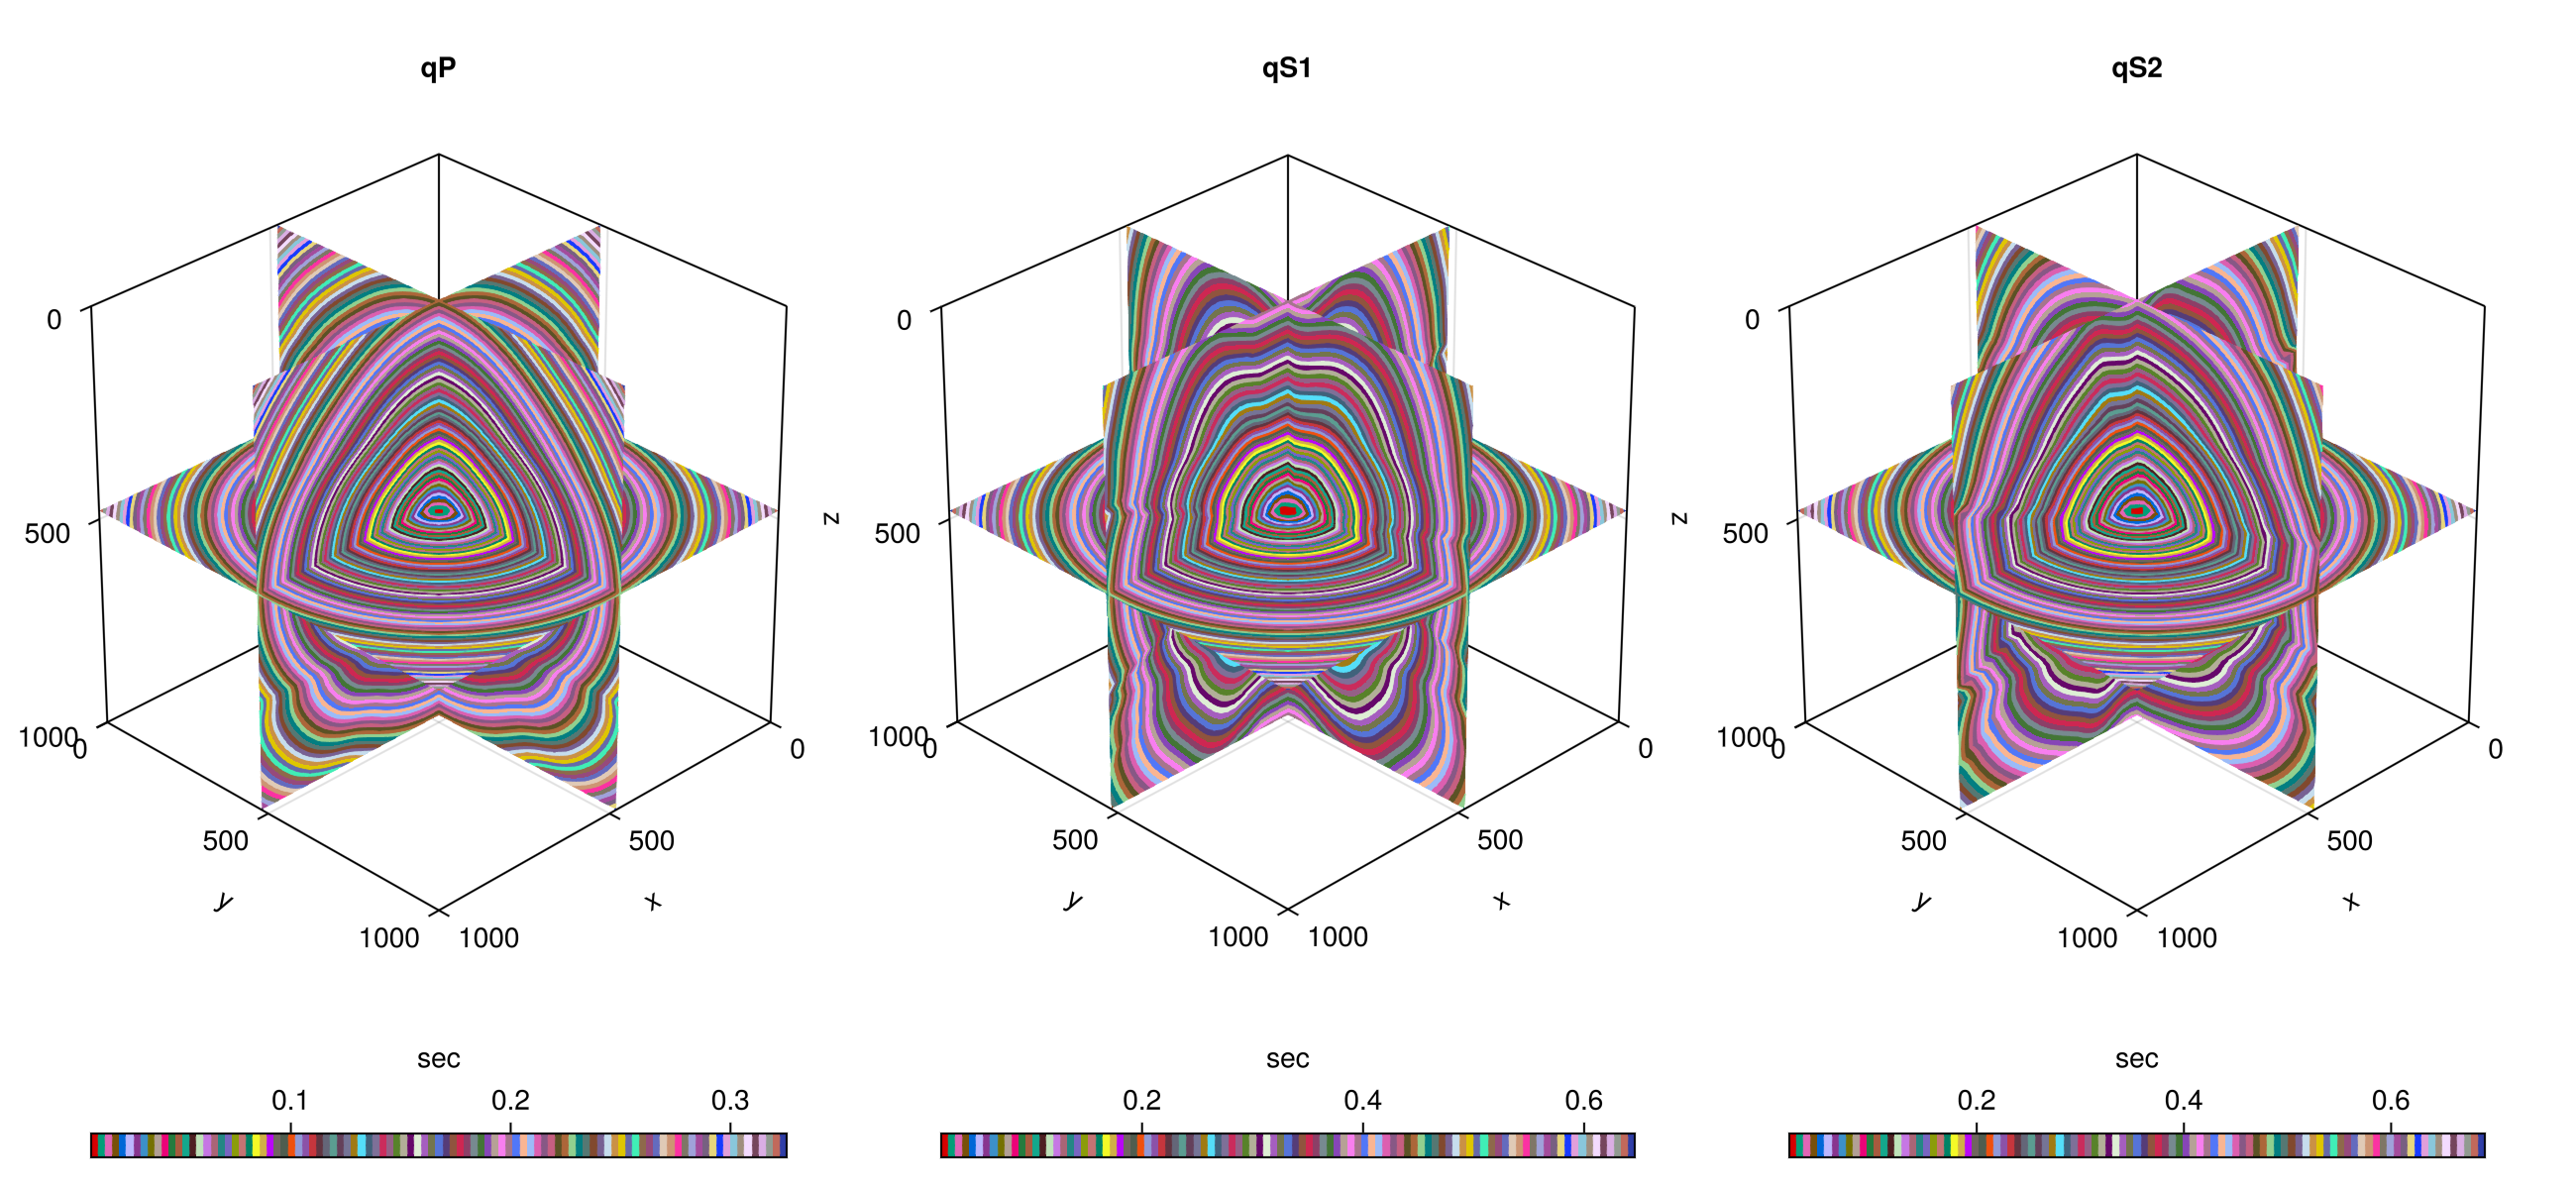

GLMakie.Screen(...)

In [ ]:
# plot 
elevation = deg2rad(30)
azimuth = deg2rad(45)
cmap=:glasbey_bw_minc_20_n256

fig = Figure(size=(1300,600)) 
names = ["qP", "qS1", "qS2"]
imgs = [tt_p, tt_s1, tt_s2]

xmid = Int(floor(length(x_coords)/2))
ymid = Int(floor(length(y_coords)/2))
zmid = Int(floor(length(z_coords)/2))

for (i, img) in enumerate(imgs)
    
    XY = img[:, :, zmid]
    XZ = img[:, ymid, :]
    YZ = img[xmid, :, :]

    global_min = minimum([minimum(XY), minimum(XZ), minimum(YZ)])
    global_max = maximum([maximum(XY), maximum(XZ), maximum(YZ)])
    colorrange = (global_min, global_max)

    ax = Axis3(fig[1,i]; aspect=(1,1,1), zreversed=true, title=names[i],
            elevation=elevation, azimuth=azimuth, perspectiveness=0.1)
            
    xy = contourf!(ax, x_coords, y_coords, XY, 
            levels = range(global_min, global_max, length = 100),colormap=cmap,
            transformation=(:xy, z_coords[zmid]))

    xz = contourf!(ax, x_coords, z_coords, XZ,
                levels = range(global_min, global_max, length = 100),colormap=cmap,
                transformation=(:xz, y_coords[ymid]))

    yz = contourf!(ax, y_coords, z_coords, YZ, 
                levels = range(global_min, global_max, length = 100),colormap=cmap,
                transformation=(:yz, x_coords[xmid]))

    xlims!(ax, x_coords[1], x_coords[end])
    ylims!(ax, y_coords[1], y_coords[end])
    zlims!(ax, z_coords[end], z_coords[1])

    Colorbar(fig[2,i], xy, vertical=false, label="sec")

end
    
display(fig)